# Hovmoller FWC and SIC distribution

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import time
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:32775")
client

<Client: 'tcp://127.0.0.1:32775' processes=8 threads=32, memory=123.95 GiB>

**PROCEDURE:**

1. Select days after sea ice minimum each year.
2. Mask grid cells where SIC>15% at minimum.
3. Calculate FWC in each grid cell, then bin grid cells (e.g., 0.1 m increments).
4. For each FWC bin and timestep, compute percent grid cells >15% SIC and compute mean SIC.

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

# open THETA zarr store - [degC]
theta_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options).THETA

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

In [7]:
# carve out beaufort region
salt_beaufort = salt_da.isel(i=slice(450,750),j=slice(110,390))
theta_beaufort = theta_da.isel(i=slice(450,750),j=slice(110,390))
ice_beaufort = ice_da.isel(i=slice(450,750),j=slice(110,390))

HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(110,390))

## 1. Select days after sea ice minimum each year and mask SIC>15%

In [99]:
ice_beaufort = ice_da.sel(time=slice('2014','2020')).isel(i=slice(450,750),j=slice(110,390))
beaufort_area = HH_grid.isel(i=slice(450,750),j=slice(110,390)).rAc

In [106]:
# calculating minimum based on extend (count grid cells where ice concentration >= 15% and sum their areas)

# salculate sea ice extent: sum the area of grid cells where SIC >= 15%
ice_extent = ((ice_beaufort >= 15) * beaufort_area).sum(dim=['i', 'j'])
ice_extent = ice_extent.where(ice_extent != 0)

# group by year
grouped = ice_extent.groupby("time.year")

# find the day of the minimum extent for each year
min_ice_dates = []
for year, data in grouped:
    sic_min_yr = data['time']
    min_day_tmp = sic_min_yr[data.argmin().values].values  # Get the time corresponding to min extent
    min_ice_dates.append(min_day_tmp)
    print(f"{year}: Minimum extent on {min_day_tmp}")

2014: Minimum extent on 2014-09-23T12:00:00.000000000
2015: Minimum extent on 2015-09-16T12:00:00.000000000
2016: Minimum extent on 2016-09-01T12:00:00.000000000
2017: Minimum extent on 2017-10-07T12:00:00.000000000
2018: Minimum extent on 2018-09-21T12:00:00.000000000
2019: Minimum extent on 2019-09-24T12:00:00.000000000
2020: Minimum extent on 2020-09-06T12:00:00.000000000


In [107]:
# generate daily timestamps from each min date to Dec 31 of that year
date_arrays = [np.arange(np.datetime64(date), np.datetime64(f"{str(date)[:4]}-12-31") + np.timedelta64(1, 'D'), np.timedelta64(1, 'D'))
               for date in min_ice_dates]

# concatenate into one array
full_date_array = np.concatenate(date_arrays)

In [108]:
# select days after sea ice minimum for SIC and salinity

# select all timesteps after sea ice minimum each year
ice_yrs = ice_beaufort.sel(time=full_date_array)
salt_yrs = salt_beaufort.sel(time=full_date_array).isel(k=slice(0,8)) # only upper 12 m

In [109]:
# list to store yearly masks
mask_list = []

for date in min_ice_dates:
    year = str(date.astype('datetime64[Y]'))  # Extract year as a string
    
    # select all days from the minimum ice date to Dec 31
    yearly_data = ice_yrs.sel(time=slice(str(date), f"{year}-12-31"))

    # get sea ice concentration on the minimum ice date
    sic_min_day = ice_yrs.sel(time=date)

    # create a mask for grid cells where sic >= 15% on the minimum ice date
    mask = sic_min_day >= 15  # 2D (i, j)

    # expand mask along time dimension to match yearly_data
    mask_expanded = mask.expand_dims(dim={"time": yearly_data.time}, axis=0)

    # store in list
    mask_list.append(mask_expanded)

# combine all yearly masks
sic_yrs_mask = xr.concat(mask_list, dim="time").combine_first(ice_yrs * 0)  # Align time with ice_yrs

# apply mask to sea ice ds
land_sic_mask_yr = (~sic_yrs_mask.astype(bool)) & (HH_grid.isel(i=slice(450,750),j=slice(110,390),k=0).mask_basin)
ice_yrs_masked = ice_yrs.where(land_sic_mask_yr)

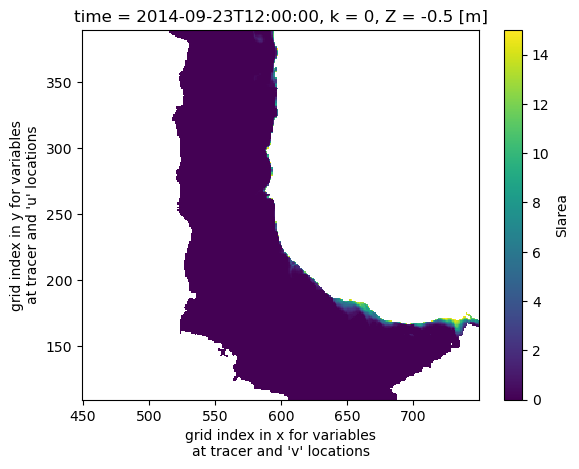

In [110]:
ice_yrs_masked.sel(time='2014').isel(time=0).plot();

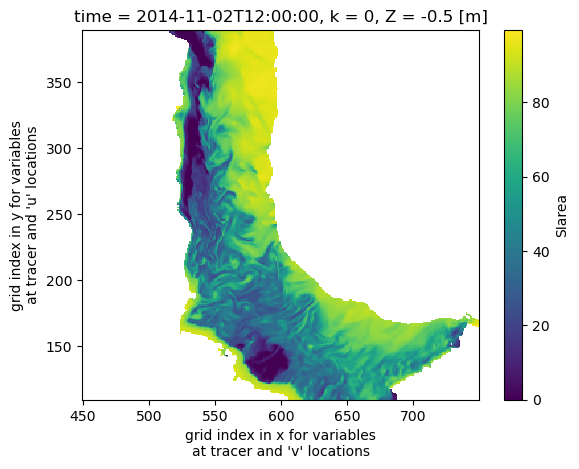

In [111]:
ice_yrs_masked.sel(time='2014').isel(time=40).plot();

## 2. Calculate FWC and bin data into 100 bins

In [112]:
def calculate_fwc(salt_da, salt_ref, dz):
    """
    Calculate the freshwater content (fwc)

    Parameters:
    salt_da (xr.DataArray): Salinity data array with a 'k' dimension.
    salt_ref (float): Reference salinity value.
    dz (xr.DataArray): Layer thickness data array with the same 'k' dimension.

    Returns:
    xr.DataArray: Freshwater content summed over the 'k' dimension.
    """
    fwc = ((salt_ref - salt_da) / salt_ref * dz).sum(dim='k')
    return fwc

In [113]:
# calculate FWC

# define reference salinity
salt_ref = 34.8

dz = HH_grid.isel(i=slice(450,750),j=slice(110,390)).drF.isel(k=slice(0,8))
fwc_beaufort_yrs = calculate_fwc(salt_yrs, salt_ref, dz)

In [114]:
# mask land grid cells and where SIC>15% on ice minimum date
# ice_yrs_masked = ice_yrs.where(land_sic_mask_yr)
fwc_yrs_masked = fwc_beaufort_yrs.where(land_sic_mask_yr)

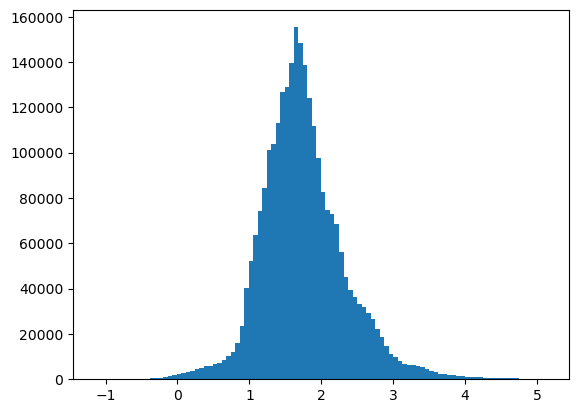

In [121]:
plt.hist(np.ravel(fwc_yrs_masked.sel(time='2014').values),100);

In [117]:
# define FWC bins
fwc_bins = np.linspace(0,5,99)
fwc_bins = np.append(fwc_bins, 8) # total of 100

In [118]:
len(fwc_bins)

100

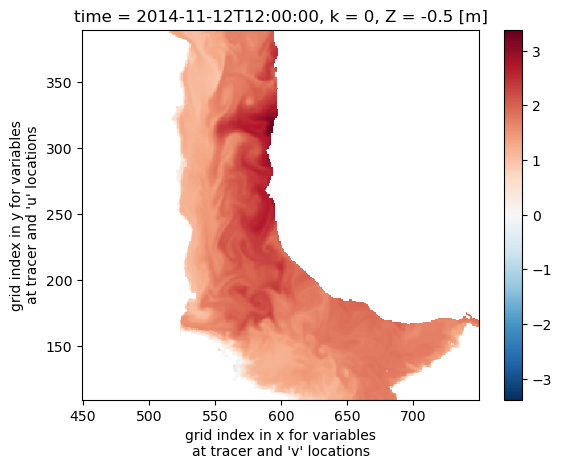

In [120]:
fwc_yrs_masked.isel(time=50).plot();

In [122]:
# bin each grid cell into FWC intervals
# use np.digitize to bin the values according to fwc_bins
fwc_binned_yrs = np.digitize(fwc_yrs_masked, fwc_bins, right=False)

In [123]:
fwc_binned_yrs.shape

(733, 280, 300)

In [125]:
# sanity check
print(fwc_binned_yrs[0,110,145]) # index = 92
print(fwc_bins[92])
print(fwc_bins[91:93])
print(fwc_yrs_masked.values[0,110,145]) # looks good

92
4.6938775510204085
[4.64285714 4.69387755]
4.676286357243855


In [126]:
fwc_binned_da = xr.DataArray(data = fwc_binned_yrs, dims=['time', 'j', 'i'],\
                             coords={'time': fwc_yrs_masked.time.values, 'j': fwc_yrs_masked.j.values, 'i': fwc_yrs_masked.i.values})

In [127]:
# mask out land and sea ice
fwc_binned_da = fwc_binned_da.where(land_sic_mask_yr)

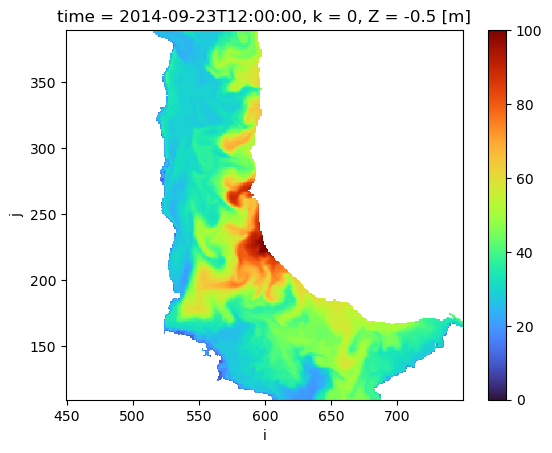

In [130]:
fwc_binned_da.isel(time=0).plot(vmin=0,vmax=100,cmap='turbo');

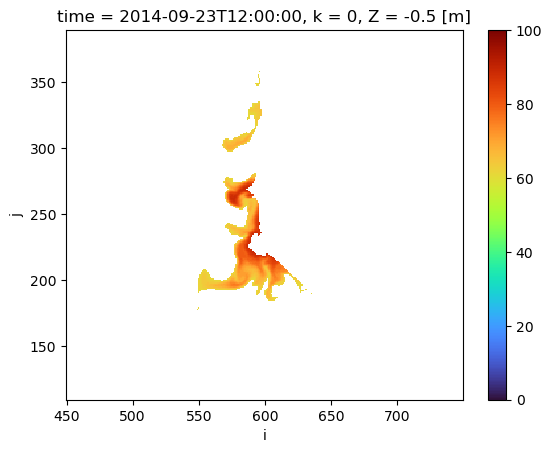

In [131]:
fwc_binned_da.isel(time=0).where((fwc_binned_da.isel(time=0)>60) & (fwc_binned_da.isel(time=0)<90)).plot(vmin=0,vmax=100,cmap='turbo');

In [134]:
ice_yrs_masked.shape

(733, 280, 300)

In [133]:
fwc_binned_da.shape

(733, 280, 300)

## 3a. Group by bins and calculate mean SIC for each bin for every time step

In [143]:
# group by bins and calculate % grid cells over 15%
ice_grouped_mean = ice_yrs_masked.groupby(fwc_binned_da).mean(dim=['i','j'])

In [158]:
np.round(fwc_bins,1)[::10]

array([0. , 0.5, 1. , 1.5, 2. , 2.6, 3.1, 3.6, 4.1, 4.6])

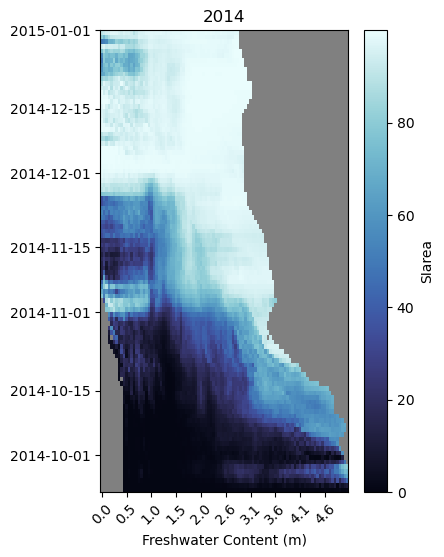

In [162]:
# sanity check
fig, ax = plt.subplots(1,1,figsize=[4,6])
ax.set_facecolor('gray')
ice_grouped_mean.sel(time='2014').plot(ax=ax,y='time',x='group',cmap=cmocean.cm.ice);
ax.set_xticks(ice_grouped_mean.group.values[::10])
ax.set_xticklabels(np.round(fwc_bins,1)[::10],rotation=45);
ax.set_ylabel("")
ax.set_title('2014')
ax.set_xlabel("Freshwater Content (m)");

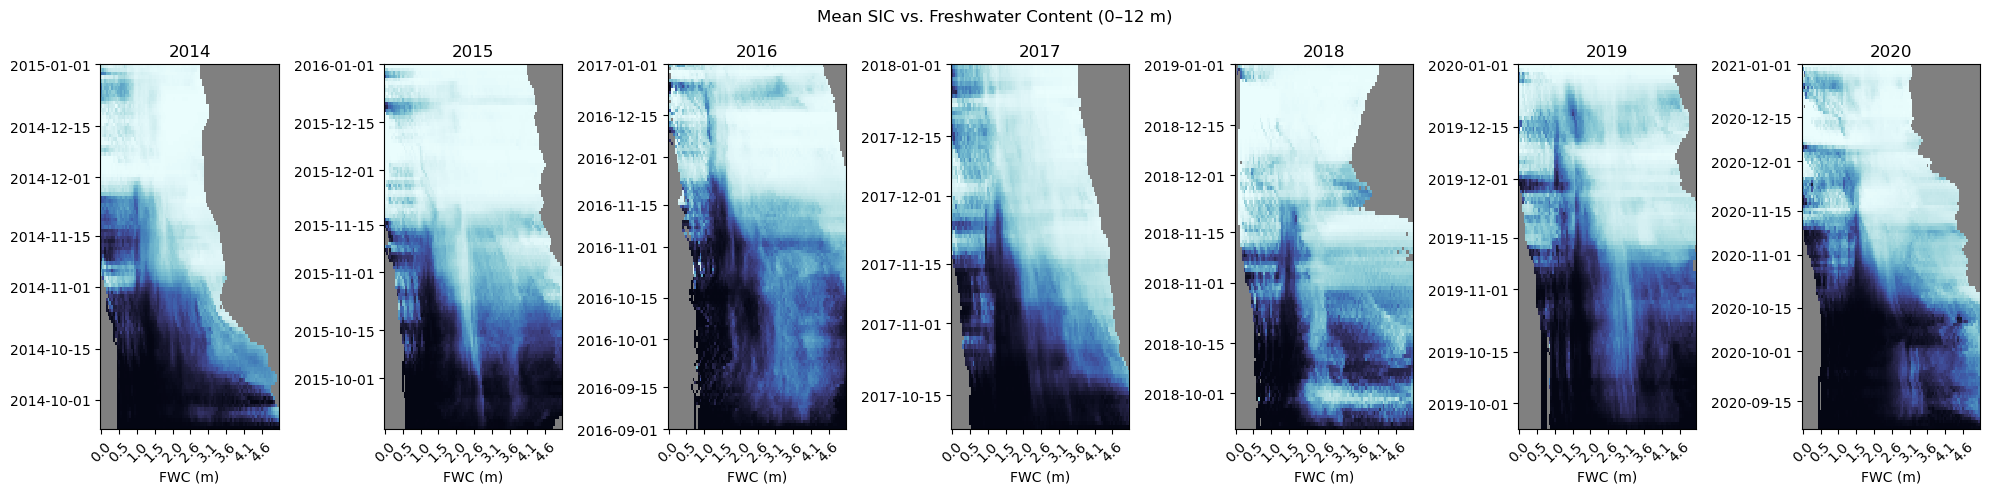

In [165]:
fig, axs = plt.subplots(1, 7, sharex=True, figsize=[20, 5])
years = np.arange(2014, 2021)

for year, ax in zip(years, axs):  # Use zip to iterate over both lists
    ice_grouped_mean.sel(time=str(year)).plot(ax=ax, y='time', x='group', cmap=cmocean.cm.ice, add_colorbar=False)
    ax.set_facecolor('gray')
    ax.set_xticks(ice_grouped_mean.group.values[::10])
    ax.set_xticklabels(np.round(fwc_bins, 1)[::10], rotation=45)
    ax.set_ylabel("")
    ax.set_title(str(year))  # Ensure year is a string for the title
    ax.set_xlabel("FWC (m)")

plt.suptitle("Mean SIC vs. Freshwater Content (0–12 m)")
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

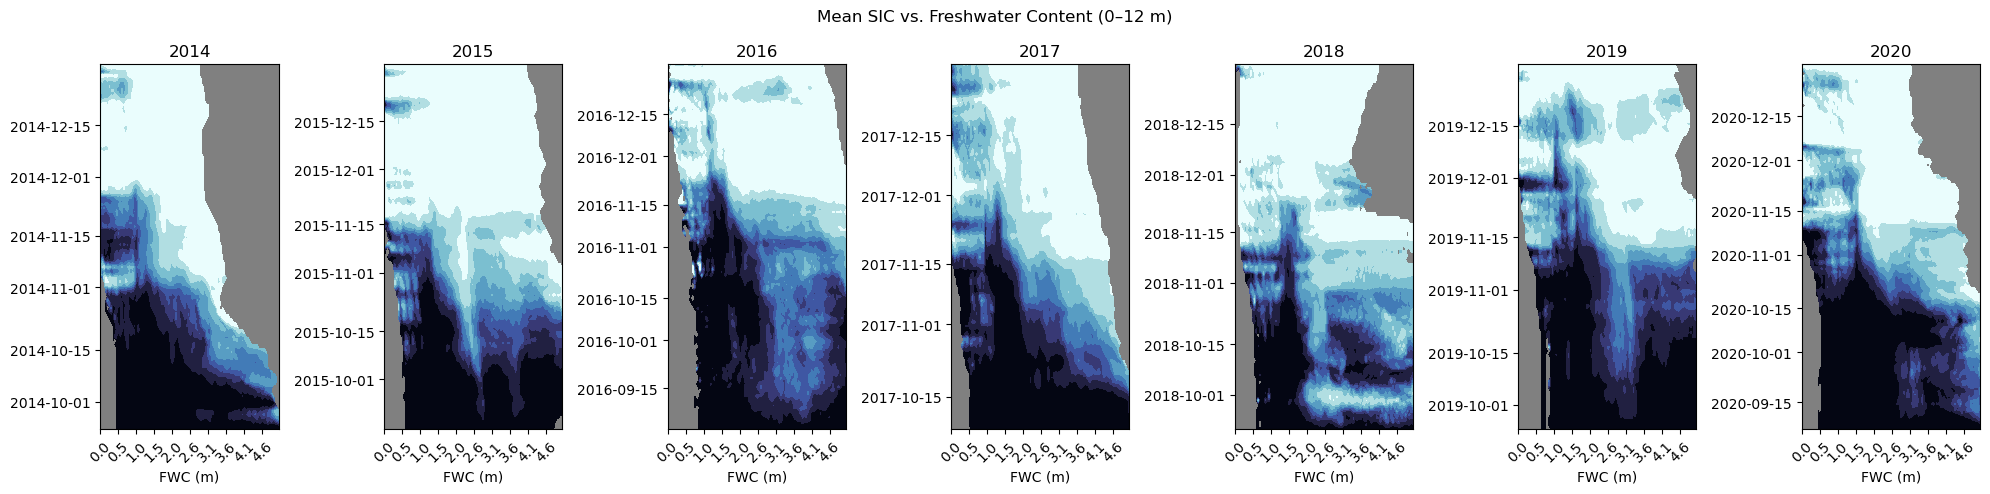

In [168]:
fig, axs = plt.subplots(1, 7, sharex=True, figsize=[20, 5])
years = np.arange(2014, 2021)

for year, ax in zip(years, axs):  # Use zip to iterate over both lists
    ice_grouped_mean.sel(time=str(year)).plot.contourf(ax=ax, y='time', x='group',levels=[0,15,30,40,50,60,70,80,90,100], cmap=cmocean.cm.ice, add_colorbar=False)
    ax.set_facecolor('gray')
    ax.set_xticks(ice_grouped_mean.group.values[::10])
    ax.set_xticklabels(np.round(fwc_bins, 1)[::10], rotation=45)
    ax.set_ylabel("")
    ax.set_title(str(year))  # Ensure year is a string for the title
    ax.set_xlabel("FWC (m)")

plt.suptitle("Mean SIC vs. Freshwater Content (0–12 m)")
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

## 3b. Group by bins and calculate percentage of grid cells where SIC>15% for each FWC bin

In [89]:
# threshold for sea ice concentration
threshold = 15  # Percent

# convert to a binary mask where sea ice concentration > 15%
ice_binary = (ice_yr_masked > threshold).astype(int)

In [90]:
# count the number of cells above threshold per bin
count_above_threshold = ice_binary.groupby(fwc_binned_da).sum(dim=["i", "j"])

# count total number of grid cells in each bin
total_count_per_bin = fwc_binned_da.groupby(fwc_binned_da).count(dim=["i", "j"])

# compute percentage of grid cells > 15% sea ice concentration
percent_above_threshold = (count_above_threshold / total_count_per_bin) * 100

In [91]:
percent_above_threshold

<xarray.DataArray (time: 120, group: 100)> Size: 96kB
dask.array<mul, shape=(120, 100), dtype=float64, chunksize=(1, 100), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 960B 2014-09-03T12:00:00 ... 2014-12-31T12...
    k        int32 4B 0
    Z        float32 4B -0.5
  * group    (group) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99

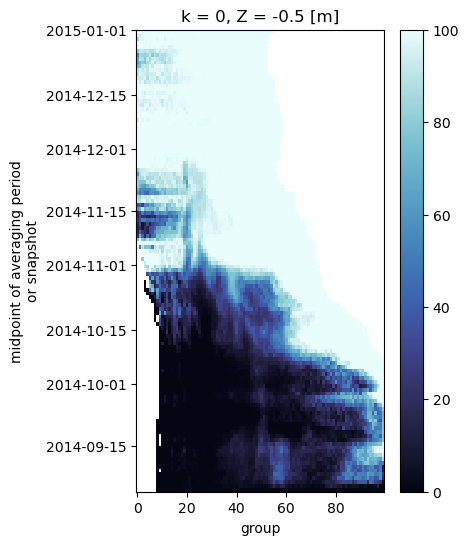

In [93]:
percent_above_threshold.plot(y='time',x='group',figsize=[4,6],cmap=cmocean.cm.ice);